In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')
# chart look clean
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
print("All libraries loaded success")

All libraries loaded success


In [11]:
#footnote 7: keeps 'None' as string
df_raw=pd.read_csv('../hotel_bookings (1).csv',keep_default_na=False)
print(f"Raw data:{len(df_raw)} raw")
#date text -> actual date
for col in['booking_date','checkin_date','checkout_date','customer_signup_date']:
    df_raw[col]=pd.to_datetime(df_raw[col])
#footnote 1: invalid stay
df_raw['is_invalid_stay']=df_raw['checkout_date']<=df_raw['checkin_date']
#footnote 2: booking before signup
df_raw['is_booking_before_signup']=df_raw['booking_date']<df_raw['customer_signup_date']
#footnote 3: zero rooms
df_raw['is_zero_rooms']=df_raw['num_rooms']==0
#footnote 5: cancelled but have a review
df_raw['is_cancelled_with_review']=((df_raw['booking_status']=='Cancelled')&(df_raw['review_rating']!=''))
#removing 1 and 3 and keeping 2 because they might be still valid
df=df_raw[(~df_raw['is_invalid_stay'])&(~df_raw['is_zero_rooms'])].copy()
#lead time will be neede for cancellation analysis
df['lead_time']=(df['checkin_date']-df['booking_date']).dt.days
df['lead_time_bucket']=pd.cut(df['lead_time'],bins=[-1,7,30,90,999],labels=['0-7 days','8-30 days','31-90 days','90+ days'])
print(f"Clean data:{len(df)} rows")
print(f"\nData quality summary:")
print(f"Invalid stay removed:{df_raw['is_invalid_stay'].sum()}")
print(f"Zero-room rows removed :{df_raw['is_zero_rooms'].sum()}")
print(f"Booking-before-signup:{df_raw['is_booking_before_signup'].sum()} (flagged,kept)")
print(f"Cancelled-with-review:{df_raw['is_cancelled_with_review'].sum()}(flagged,kept)")

Raw data:12000 raw
Clean data:11821 rows

Data quality summary:
Invalid stay removed:120
Zero-room rows removed :60
Booking-before-signup:163 (flagged,kept)
Cancelled-with-review:50(flagged,kept)


In [14]:
#A1
print("A1: Invalid Stay")
print(f"Answer:{df_raw['is_invalid_stay'].sum()} bookings")
#A2
print("A2:Review Ratings by Segment")
has_review=df[df['review_rating']!=''].copy()
has_review['review_rating']=pd.to_numeric(has_review['review_rating'])
has_review_norm=has_review.copy()
has_review_norm.loc[has_review_norm['customer_segment']=='Corporate','review_rating']/=2
print("RAW (before normalizing):")
print(has_review.groupby('customer_segment')['review_rating'].agg(['min','max','mean','count']))
print("\nNormalized(Corporate%2):")
print(has_review_norm.groupby('customer_segment')['review_rating'].agg(['min','max','mean','count']))
#A3
print("\n=== A3: Realized Revenue – Luxury ===")
luxury_revenue = df[
    (df['booking_status'] == 'Completed') &
    (df['property_type'] == 'Luxury')
]['total_amount'].sum()
print(f"Answer: ₹{luxury_revenue:,.2f}")

A1: Invalid Stay
Answer:120 bookings
A2:Review Ratings by Segment
RAW (before normalizing):
                  min   max      mean  count
customer_segment                            
Corporate         3.0  10.0  7.247439   1269
Group             1.0   5.0  3.761246    578
Individual        1.0   5.0  3.769446   3214

Normalized(Corporate%2):
                  min  max      mean  count
customer_segment                           
Corporate         1.5  5.0  3.623719   1269
Group             1.0  5.0  3.761246    578
Individual        1.0  5.0  3.769446   3214

=== A3: Realized Revenue – Luxury ===
Answer: ₹90,694,052.93


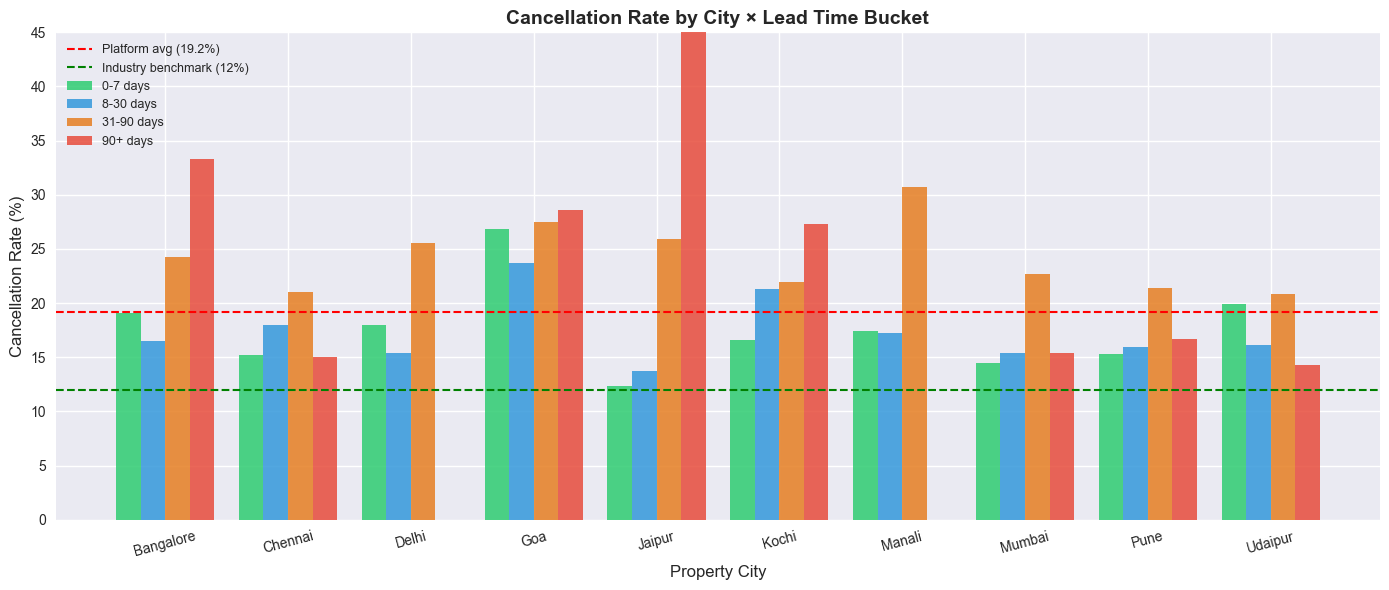

Chart saved!
TOP 3 SLICES BY CANCELLATION RATE (worst % performers)
             slice  cancel_rate  cancellations  total_bookings
   Jaipur|90+ days        100.0              1               1
Bangalore|90+ days         33.3              5              15
 Manali|31-90 days         30.7             67             218

=== TOP 3 SLICES BY CANCELLATION VOLUME (most actual cancellations) ===
             slice  cancel_rate  cancellations  total_bookings
 Chennai|8-30 days         18.0            125             696
   Pune|31-90 days         21.4            121             565
Chennai|31-90 days         21.1            120             570
Platform total bookings : 11821
Platform total cancelled: 2264
Platform cancel rate    : 19.2%


In [27]:
# calculate the cancaltion rate
pivot=df.groupby(
            ['property_city','lead_time_bucket'],
            observed=True
)['booking_status'].apply(
   lambda x: (x== 'Cancelled').sum()/len(x)*100
).reset_index()
pivot.columns=['City','Lead Time','Cancellation Rate (%)']

#chart
fig,ax=plt.subplots(figsize=(14,6))
cities=pivot['City'].unique()
lead_bucket=pivot['Lead Time'].unique()
x=np.arange(len(cities))
width=0.2
colors = ['#2ecc71', '#3498db', '#e67e22', '#e74c3c']
for i,bucket in enumerate(lead_bucket):
    subset=pivot[pivot['Lead Time']==bucket]
    rates=[subset[subset['City']==c]['Cancellation Rate (%)'].values[0]
           if c in subset['City'].values else 0
           for c in cities]
    ax.bar(x+i*width, rates, width, label=bucket, color=colors[i], alpha=0.85)
# Formatting
ax.axhline(y=19.2, color='red', linestyle='--', linewidth=1.5, label='Platform avg (19.2%)')
ax.axhline(y=12.0, color='green', linestyle='--', linewidth=1.5, label='Industry benchmark (12%)')
ax.set_xlabel('Property City', fontsize=12)
ax.set_ylabel('Cancellation Rate (%)', fontsize=12)
ax.set_title('Cancellation Rate by City × Lead Time Bucket', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(cities, rotation=15)
ax.legend(loc='upper left', fontsize=9)
ax.set_ylim(0, 45)

plt.tight_layout()
plt.savefig('cancellation_landscape.png', dpi=150)
plt.show()
print("Chart saved!")
#A2
summary=df.groupby(
     ['property_city','lead_time_bucket'],
     observed=True
).agg(
    total_bookings=('booking_status','count'),
    cancellations=('booking_status',lambda x:(x=='Cancelled').sum())
).reset_index()
#Cancelled rate
summary['cancel_rate']=(summary['cancellations']/summary['total_bookings']*100).round(1)
#Redable label
summary['slice']=summary['property_city']+'|'+summary['lead_time_bucket'].astype(str)
#top 3 rating
top_rate=summary.nlargest(3,'cancel_rate')[['slice','cancel_rate','cancellations','total_bookings']]
#top 3 volume
top_volume = summary.nlargest(3, 'cancellations')[['slice', 'cancel_rate', 'cancellations', 'total_bookings']]
print("TOP 3 SLICES BY CANCELLATION RATE (worst % performers)")
print(top_rate.to_string(index=False))
print()
print("=== TOP 3 SLICES BY CANCELLATION VOLUME (most actual cancellations) ===")
print(top_volume.to_string(index=False))
#platform context
total_bookings   = len(df)
total_cancelled  = (df['booking_status'] == 'Cancelled').sum()
print(f"Platform total bookings : {total_bookings}")
print(f"Platform total cancelled: {total_cancelled}")
print(f"Platform cancel rate    : {total_cancelled/total_bookings*100:.1f}%")

In [35]:
TARGET_CITY='Manali'
TARGET_BUCKET='31-90 days'
our_slice=df[
    (df['property_city']==TARGET_CITY)&
    (df['lead_time_bucket']==TARGET_BUCKET)
    ]
rest=df[
    ~(
        (df['property_city']==TARGET_CITY)&
        (df['lead_time_bucket']==TARGET_BUCKET)
    )
    ]
print(f"Our slice:{len(our_slice)} bookings,"
      f"{(our_slice['booking_status']=='Cancelled').sum()} cancelled, "
      f"{(our_slice['booking_status']=='Cancelled').mean()*100:.1f}% rate")

print(f"Rest of platform: {len(rest)} bookings, "
      f"{(rest['booking_status']=='Cancelled').sum()} cancelled, "
      f"{(rest['booking_status']=='Cancelled').mean()*100:.1f}% rate")
#time effect
print("\nHYPOTHESIS 1: Is 31-90 days always high everywhere?")
h1 = df[df['lead_time_bucket'] == TARGET_BUCKET].groupby(
    'property_city'
)['booking_status'].apply(
    lambda x: (x == 'Cancelled').mean() * 100
).round(1).sort_values(ascending=False)
print(h1)
#Channel mix effect
manali_channel=(
    df[df['property_city']==TARGET_CITY]['booking_channel']
    .value_counts(normalize=True)*100
).round(1)
rest_channel = (
    df[df['property_city'] != TARGET_CITY]['booking_channel']
    .value_counts(normalize=True) * 100
).round(1)
channel_compare=pd.DataFrame({
    'Manali%':manali_channel,
    'Platform%':rest_channel
}).fillna(0)
print(channel_compare)
print("\nCancel rate by channel (platform wide):")
print(df.groupby('booking_channel')['booking_status'].apply(
    lambda x: (x == 'Cancelled').mean() * 100
).round(1))
#Hyp 3 :city+ season
df['checkin_month']     = df['checkin_date'].dt.strftime('%b')
df['checkin_month_num'] = df['checkin_date'].dt.month

monthly = df[df['property_city'].isin(['Manali', 'Goa', 'Mumbai'])].groupby(
    ['property_city', 'checkin_month_num', 'checkin_month']
)['booking_status'].apply(
    lambda x: (x == 'Cancelled').mean() * 100
).round(1).reset_index()
monthly.columns = ['City', 'Month_Num', 'Month', 'Cancel Rate']
monthly = monthly.sort_values(['City', 'Month_Num'])

print(monthly[['City', 'Month', 'Cancel Rate']].to_string(index=False))

Our slice:218 bookings,67 cancelled, 30.7% rate
Rest of platform: 11603 bookings, 2197 cancelled, 18.9% rate

HYPOTHESIS 1: Is 31-90 days always high everywhere?
property_city
Manali       30.7
Goa          27.5
Jaipur       25.9
Delhi        25.5
Bangalore    24.2
Mumbai       22.7
Kochi        21.9
Pune         21.4
Chennai      21.1
Udaipur      20.9
Name: booking_status, dtype: float64
                  Manali%  Platform%
booking_channel                     
OTA                  38.2       35.2
Corporate Portal     24.6       26.9
Travel Agent         21.2       20.1
Direct Website       15.9       17.8

Cancel rate by channel (platform wide):
booking_channel
Corporate Portal    20.2
Direct Website      14.8
OTA                 22.0
Travel Agent        16.7
Name: booking_status, dtype: float64
  City Month  Cancel Rate
   Goa   Jan         15.1
   Goa   Feb         21.6
   Goa   Mar         30.4
   Goa   Apr         14.7
   Goa   May         20.5
   Goa   Jun         50.9
   Goa   

In [38]:
print("CURRENT STATE")
platform_bookings=len(df)
platform_cancelled=(df['booking_status']=='Cancelled').sum()
platform_rate=platform_cancelled/platform_bookings*100
print(f"Platform bookings:{platform_bookings}")
print(f"Platform cancellations:{platform_cancelled}")
print(f"Platform cancel rate:{platform_rate:.1f}%")
target=df[
    (df['property_city']=='Manali')&
    (df['lead_time_bucket']=='31-90 days')
    ]
target_bookings=len(target)
target_cancelled=(target['booking_status']=='Cancelled').sum()
target_rate=target_cancelled/target_bookings*100
print(f"\nManali | 31-90 days bookings     : {target_bookings}")
print(f"Manali | 31-90 days cancellations: {target_cancelled}")
print(f"Manali | 31-90 days cancel rate  : {target_rate:.1f}%")
print("\n" + "=" * 55)
print("INTERVENTION: 20% Non-Refundable Deposit + 8% Discount")
print("=" * 55)
# We use conservative 30% and optimistic 50% for our range
reduction_conservative = 0.30
reduction_optimistic   = 0.50
saved_conservative = target_cancelled * reduction_conservative
saved_optimistic   = target_cancelled * reduction_optimistic
print(f"\nCancellations in target slice   : {target_cancelled}")
print(f"Expected savings (conservative) : {saved_conservative:.0f} cancellations (30% reduction)")
print(f"Expected savings (optimistic)   : {saved_optimistic:.0f} cancellations (50% reduction)")
print("\n" + "=" * 55)
print("EXPECTED PLATFORM-WIDE IMPACT")
print("=" * 55)
new_cancelled_conservative = platform_cancelled - saved_conservative
new_cancelled_optimistic   = platform_cancelled - saved_optimistic
new_rate_conservative = new_cancelled_conservative / platform_bookings * 100
new_rate_optimistic   = new_cancelled_optimistic   / platform_bookings * 100
pp_conservative = platform_rate - new_rate_conservative
pp_optimistic   = platform_rate - new_rate_optimistic
print(f"\nCurrent platform rate           : {platform_rate:.1f}%")
print(f"New rate (conservative)         : {new_rate_conservative:.1f}%")
print(f"New rate (optimistic)           : {new_rate_optimistic:.1f}%")
print(f"\nExpected reduction              : {pp_conservative:.1f}pp to {pp_optimistic:.1f}pp")
print(f"Board target                    : 5.0pp reduction (to 14.2%)")
print(f"This intervention covers        : "
      f"{pp_conservative/5.0*100:.0f}% to {pp_optimistic/5.0*100:.0f}% of the board target")
print("\n" + "=" * 55)
print("RISK / COLLATERAL EFFECT")
print("=" * 55)
print("""
Risk: Demand reduction in the target slice.
Customers who were planning to book Manali 31-90 days
in advance may choose competitors offering free cancellation
instead of committing to a deposit.

Mitigation: Offer the deposit option as OPT-IN with a
visible discount incentive — not as a mandatory policy.
This preserves customer choice while rewarding commitment.
""")

CURRENT STATE
Platform bookings:11821
Platform cancellations:2264
Platform cancel rate:19.2%

Manali | 31-90 days bookings     : 218
Manali | 31-90 days cancellations: 67
Manali | 31-90 days cancel rate  : 30.7%

INTERVENTION: 20% Non-Refundable Deposit + 8% Discount

Cancellations in target slice   : 67
Expected savings (conservative) : 20 cancellations (30% reduction)
Expected savings (optimistic)   : 34 cancellations (50% reduction)

EXPECTED PLATFORM-WIDE IMPACT

Current platform rate           : 19.2%
New rate (conservative)         : 19.0%
New rate (optimistic)           : 18.9%

Expected reduction              : 0.2pp to 0.3pp
Board target                    : 5.0pp reduction (to 14.2%)
This intervention covers        : 3% to 6% of the board target

RISK / COLLATERAL EFFECT

Risk: Demand reduction in the target slice.
Customers who were planning to book Manali 31-90 days
in advance may choose competitors offering free cancellation
instead of committing to a deposit.

Mitigation: